# TP7 - Numerical Differentiation

Ce Jupyter notebook est la solution commentée du TP7 du cours LBRI1271. Vous trouverez ici plus de détails sur la solution, ainsi que des explications sur l'implémentation de la méthode des différences finies vue au cours et lors du TP.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline

## Partie 1 : Gradient de pression
Dans la première partie du TP, on vous demande de calculer le gradient de pression en utilisant la méthode des différences finies. Pour utiliser cette méthode, il faut que les points où l'on a des données soient équidistants, or ce n'est pas le cas. Il faut donc, dans un premier temps, interpoler les données fournies à intervalles réguliers.


### 1.1 Interpolation sur une grille régulière
Pour construire une grille de points à intervalles réguliers, on utilise la fonction `np.linspace()`. Les deux premiers arguments sont les bornes min et max de l'intervalle, et le troisième argument est le nombre de points que l'on souhaite avoir dans l'intervalle considéré. Ici, 500 points sont suffisants. Après avoir construit l'objet d'interpolation `cs` avec la fonction `CubicSpline`, il suffit de l'utiliser sur les nouveaux points réguliers.

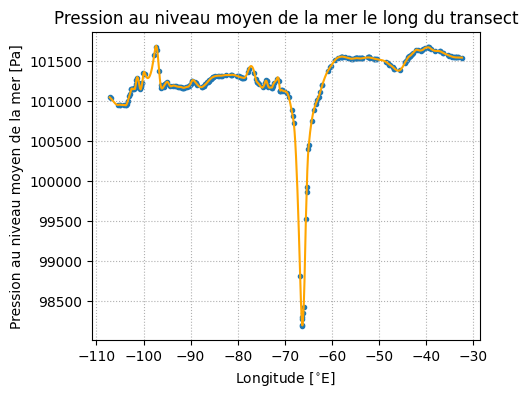

In [2]:
pressure = pd.read_csv('data_TP7/pressure_transect.csv', sep='\t')
lons = pressure['longitude']
mslp = pressure['msl']  # mslp = mean sea level pressure

cs = CubicSpline(lons, mslp)
minlon, maxlon = lons.min(), lons.max()
xs = np.linspace(minlon, maxlon, 500)
p_interp = cs(xs)

plt.figure(figsize=(5,4))
plt.title('Pression au niveau moyen de la mer le long du transect')
plt.plot(xs, p_interp, c='orange')
plt.scatter(lons, mslp, marker='.')
plt.grid(linestyle=':')
plt.xlabel(r'Longitude [$^{\circ}$E]')
plt.ylabel('Pression au niveau moyen de la mer [Pa]')
plt.show()

### 1.2 Calcul du gradient de pression

On vous demande de calculer le gradient de pression $\partial{p} / \partial{x}$ en utilisant la méthode des différences finies centrées. Le principe de cette méthode est d'approximer la dérivée par un taux de variation discret entre points voisins : pour la valeur de pression donnée $p(x_i)$ pour laquelle il existe une valeur de pression en $i-1$ et $i+1$, l'expression discrète est de la forme:
$$
   \frac{\partial{p(x)}}{\partial{x}}  \approx \frac{p(x_{i+1}) - p(x_{i-1})}{2 \Delta x}
$$
où $\Delta x$ est la distance (en mètres) entre deux points. Pour les points sur les frontières, c'est-à-dire le premier ($i=1$) et le dernier point de la grille ($i=n$), on utilisera uniquement la valeur voisine existante selon le cas.

On peut implémenter cela de deux façons différentes : soit avec une boucle (qui est la solution la plus intuitive), soit en faisant des slices, une opération très efficace quand on travaille avec des NumPy arrays.
Dans les deux cas, on commence par allouer un array de la même taille que `xs`. Comme on veut une valeur du gradient pour chaque point de pression, on connaît déjà la taille de notre array de gradient de pression, qui est `len(xs)`.

Pour la première approche avec la boucle, on souhaite visiter uniquement les valeurs de pression qui ont des voisins à gauche et à droite. Cela correspond à considérer des valeurs de $i$ allant de 1 à `len(xs)-1` (n'oubliez pas qu'en Python, on compte à partir de 0 !). On traite ensuite manuellement les cas aux frontières. Notez aussi que la valeur de la borne max de la fonction `range` est exclue. Donc si `len(xs)-1=499`, la dernière valeur de $i$ sera $498$, qui est bien l'index de l'avant-dernier élément de `dpdx`.

In [3]:
dx = 6371e3 * np.cos(18.2) * np.deg2rad(xs[1]-xs[0]) # conversion degrés -> mètres

dpdx = np.zeros(len(xs))
for i in range(1, len(xs)-1):
    dpdx[i] = (p_interp[i+1] - p_interp[i-1])/(2*dx)
dpdx[0]  = (p_interp[1] - p_interp[0])/dx
dpdx[-1] = (p_interp[-1] - p_interp[-2])/dx

Avec les slices de NumPy, l'approche pour les valeurs aux frontières est la même. Ce qui change, c'est l'approche pour les valeurs internes. Au lieu de boucler et d'aller chercher les voisins pour le i-ème élément, on va directement chercher tous les voisins de droite et tous les éléments de gauche. La première valeur interne (c.-à-d. avec un voisin à gauche et à droite) se situe à l'index 1, donc le premier voisin de droite se trouve à l'index 2. Tous les voisins de droite sont donc toutes les valeurs qui se trouvent après l'index 2 inclus : `p_interp[2:]`. À l'inverse, tous les voisins de gauche se trouvent de l'index 0 jusqu'à l'avant-avant-dernier élément : `p_interp[:-2]`.

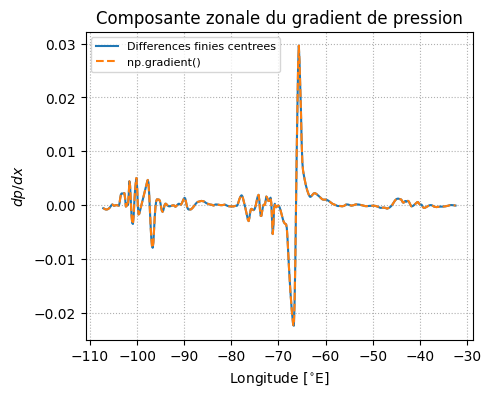

In [4]:
dpdx2 = np.zeros_like(xs)
dpdx2[1:-1] = (p_interp[2:] - p_interp[:-2])/(2*dx)
dpdx2[0]    = (p_interp[1]  - p_interp[0])/dx
dpdx2[-1]   = (p_interp[-2] - p_interp[-1])/dx

dpdx_grad = np.gradient(p_interp, dx)

plt.figure(figsize=(5,4))
plt.title('Composante zonale du gradient de pression')
plt.plot(xs, dpdx, label='Differences finies centrees')
plt.plot(xs, dpdx_grad, '--', label='np.gradient()')
plt.grid(linestyle=':')
plt.xlabel(r'Longitude [$^{\circ}$E]')
plt.ylabel(r'$dp/dx$')
plt.legend(fontsize=8)
plt.show()

## Partie 2 : Calcul de la vorticité
### 2.1 Visualisation des données de vent

Commençons par regarder les shapes des arrays avec lesquels on va travailler :

In [5]:
data = np.load('data_TP7/2d_wind_data.npy', allow_pickle=True).item()
print(data.keys())
for key, val in data.items():
    print(f'{key}: {val.shape}')

dict_keys(['lon', 'lat', 'wind_array'])
lon: (303,)
lat: (219,)
wind_array: (1, 303, 219, 2)


On a donc 303 points de longitude et 219 points de latitude. Cela définit une grille régulière de $303 \times 219$ points. Sur chaque point de cette grille, on a des valeurs de vent. Les vitesses de vent sont données pour ses deux composantes $u$ et $v$, et pour un seul temps donné. Les dimensions de `wind_array` sont donc (temps, lon, lat, n_champs). Le but de cette partie du TP est aussi de vous familiariser avec la manipulation d'arrays à plusieurs dimensions.

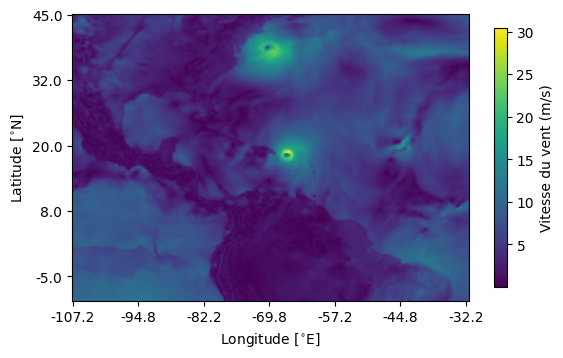

In [ ]:
lons = data['lon']
lats = data['lat']
u = data['wind_array'][...,0] # l'operateur "..." s'appelle "ellipsis"
v = data['wind_array'][...,1] # et signifie : prendre toutes les dimensions sauf la derniere

wind_speed = np.sqrt(u[0]**2 + v[0]**2).T

# Carte de la vitesse du vent
fig, ax = plt.subplots()
im = ax.imshow(wind_speed, cmap="viridis")
cbar = fig.colorbar(im, ax=ax, label='Vitesse du vent (m/s)', shrink=0.7)
ax.set_xticks(np.arange(0, len(lons), 50))
ax.set_xticklabels(np.round(lons[::50], 1))
ax.set_yticks(np.arange(0, len(lats), 50))
ax.set_yticklabels(np.round(lats[::50], 0))
ax.set_xlabel(r'Longitude [$^{\circ}$E]')
ax.set_ylabel(r'Latitude [$^{\circ}$N]')
plt.show()

On peut aussi tracer les streamlines (lignes de courant) avec la fonction `streamplot()`. Comme indiqué dans la documentation de la fonction, il faut que les arguments en x et y soient strictement croissants, or `lats` est défini du Nord au Sud : il faut donc inverser cet array. On fait ça avec `[::-1]`.

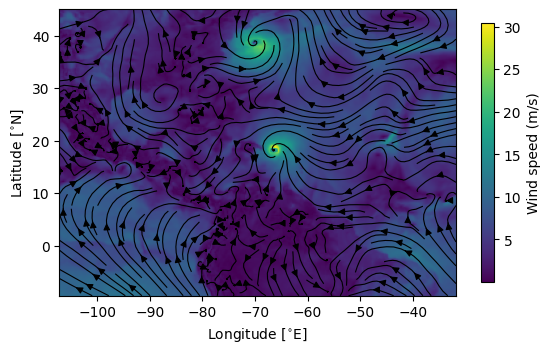

In [7]:
# Carte de la vitesse et direction du vent
u2 = data['wind_array'][...,0][0].T  # (303, 219).T
v2 = data['wind_array'][...,1][0].T  # (303, 219).T

lats2 = lats[::-1]
u2 = u2[::-1, :]
v2 = v2[::-1, :]

fig, ax = plt.subplots()
speed = np.sqrt(u2**2 + v2**2)
im = ax.imshow(speed,extent=(lons[0], lons[-1], lats2[0], lats2[-1]),origin='lower',
    cmap="viridis")
cbar = fig.colorbar(im, ax=ax, label='Wind speed (m/s)', shrink=0.7)
ax.streamplot(lons, lats2, u2, v2,density=1.65,color='k',linewidth=0.8)
ax.set_xlabel(r'Longitude [$^{\circ}$E]')
ax.set_ylabel(r'Latitude [$^{\circ}$N]')
ax.set_xlim(lons[0], lons[-1])
plt.show()

On vous demande maintenant de tracer les deux composantes et la norme de la vitesse du vent sur des graphes séparés.

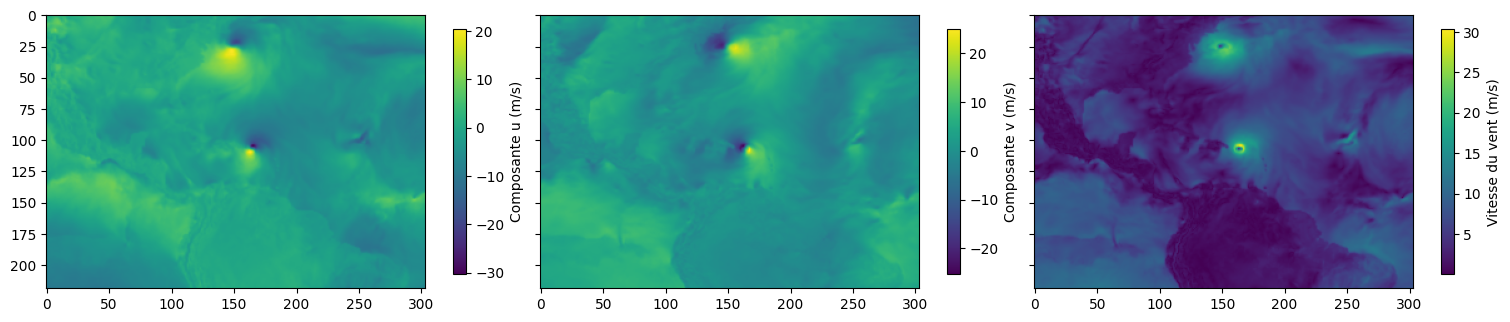

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15,5), constrained_layout=True, sharey=True)
im0 = axs[0].imshow(u[0].T, cmap="viridis")
im1 = axs[1].imshow(v[0].T, cmap="viridis")
im2 = axs[2].imshow(wind_speed, cmap="viridis")
fig.colorbar(im0, ax=axs[0], label='Composante u (m/s)', shrink=0.5)
fig.colorbar(im1, ax=axs[1], label='Composante v (m/s)', shrink=0.5)
fig.colorbar(im2, ax=axs[2], label='Vitesse du vent (m/s)', shrink=0.5)
plt.show()

### 2.2 Calcul des dérivées partielles
Pour rappel, la vorticité $\mathbf{\omega}$ pour un champ de vitesse $\mathbf{u} = (u,v)$ est définie comme :
$$
\mathbf{\omega} = \nabla \times \mathbf{u} = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y},
$$
Remarquez qu'il s'agit d'une différence de deux dérivées partielles, c'est exactement ce que vous avez fait dans la première partie du TP ! Donc, pour calculer la vorticité, il suffit simplement de calculer ces deux valeurs et de les soustraire.

On commence par calculer les $\Delta x$ et $\Delta y$ en mètres. Ensuite, on appliquera la méthode des différences finies, comme dans la première partie du TP, pour calculer $\partial{v}/ \partial{x}$ et $\partial{u}/ \partial{y}$.



In [ ]:
dx = 6371e3 * np.cos(18.2) * np.deg2rad(lons[1] - lons[0])
dy = 6371e3 * np.deg2rad(lats[1] - lats[0])

dvdx = np.zeros((len(lons), len(lats), 1))
dudy = np.zeros((len(lons), len(lats), 1))

# dérivée a l'interieur du domaine
dvdx[1:-1, :, 0] = (v[:, 2:, :] - v[:, :-2, :]) / (2 * dx)
dudy[:, 1:-1, 0] = (u[:, :, 2:] - u[:, :, :-2]) / (2 * dy)

# dérivée aux frontieres
# quand lon = lons[0] et lat = lats[0]
dvdx[0, :, 0]  = (v[:, 1,  :] - v[:, 0,  :]) / dx
dudy[:, 0, 0]  = (u[:, :, 1]  - u[:, :, 0])  / dy

# quand lon = lons[-1] et lat = lats[-1]
dvdx[-1, :, 0] = (v[:, -2, :] - v[:, -1, :]) / dx
dudy[:, -1, 0] = (u[:, :, -2] - u[:, :, -1]) / dy


# finalement, on peut calculer la vorticite
vorticity = dvdx - dudy

Et voilà ! Félicitations, vous avez calculé la vorticité du vent ! Finalement, on fait un joli plot pour voir le résultat final. Notez que `imshow()` s'attend à avoir en argument un array dont la première dimension correspond à l'axe y, donc ici la dimension des latitudes. Il faut donc transposer notre array avant de le tracer.

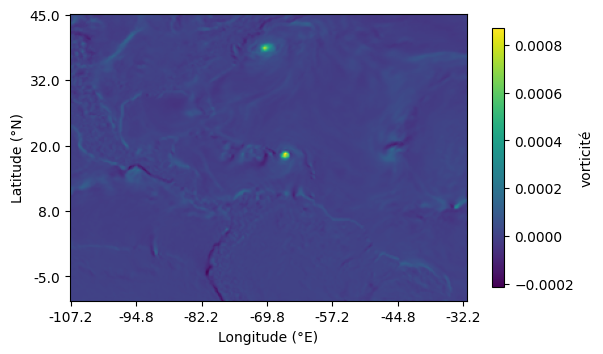

In [12]:
vorticity_data = vorticity[:,:,0].T

fig, ax = plt.subplots()
im = ax.imshow(vorticity_data)
ax.set_xticks(np.arange(0, len(lons), 50))
ax.set_xticklabels(np.round(lons[::50], 1))
ax.set_yticks(np.arange(0, len(lats), 50))
ax.set_yticklabels(np.round(lats[::50], 0))
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.colorbar(im, shrink=0.7, label='vorticité')
plt.show()